In [1]:
import os
import numpy as numpy
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

I0000 00:00:1776819248.064293   25380 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776819249.672240   25380 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776819252.725005   25380 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
path = kagglehub.dataset_download("jutrera/stanford-car-dataset-by-classes-folder")

train_dir = f"{path}/car_data/car_data/train"
test_dir = f"{path}/car_data/car_data/test"

print(train_dir)
print(test_dir)
print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

/home/codespace/.cache/kagglehub/datasets/jutrera/stanford-car-dataset-by-classes-folder/versions/2/car_data/car_data/train
/home/codespace/.cache/kagglehub/datasets/jutrera/stanford-car-dataset-by-classes-folder/versions/2/car_data/car_data/test
Train exists: True
Test exists: True


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
print("Number of classes:", len(class_names))

Found 8144 files belonging to 196 classes.
Using 6516 files for training.
Found 8144 files belonging to 196 classes.
Using 1628 files for validation.


E0000 00:00:1776819256.408193   25380 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 8041 files belonging to 196 classes.
Number of classes: 196


In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

In [5]:
NUM_CLASSES = 196

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 196)            │       251,076 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,509,060 (9.57 MB)

 Trainable params: 251,076 (980.77 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


W0000 00:00:1776819262.020222   25504 cpu_allocator_impl.cc:82] Allocation of 23970816 exceeds 10% of free system memory.
W0000 00:00:1776819262.363937   25481 cpu_allocator_impl.cc:82] Allocation of 25690112 exceeds 10% of free system memory.
W0000 00:00:1776819262.472950   25481 cpu_allocator_impl.cc:82] Allocation of 25690112 exceeds 10% of free system memory.
W0000 00:00:1776819262.549866   25481 cpu_allocator_impl.cc:82] Allocation of 77070336 exceeds 10% of free system memory.
W0000 00:00:1776819262.598458   25481 cpu_allocator_impl.cc:82] Allocation of 78452736 exceeds 10% of free system memory.


408/408 ━━━━━━━━━━━━━━━━━━━━ 224s 537ms/step - accuracy: 0.0872 - loss: 4.6089 - val_accuracy: 0.1812 - val_loss: 3.6851
Epoch 2/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 220s 540ms/step - accuracy: 0.2661 - loss: 3.1516 - val_accuracy: 0.2408 - val_loss: 3.2787
Epoch 3/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 253s 519ms/step - accuracy: 0.3775 - loss: 2.5821 - val_accuracy: 0.2764 - val_loss: 3.1058
Epoch 4/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 215s 526ms/step - accuracy: 0.4455 - loss: 2.2470 - val_accuracy: 0.2899 - val_loss: 3.0116
Epoch 5/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 275s 560ms/step - accuracy: 0.5002 - loss: 2.0150 - val_accuracy: 0.3108 - val_loss: 2.9224


In [7]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 330s 790ms/step - accuracy: 0.2785 - loss: 3.5275 - val_accuracy: 0.3010 - val_loss: 3.0826
Epoch 2/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 343s 841ms/step - accuracy: 0.4072 - loss: 2.4754 - val_accuracy: 0.3213 - val_loss: 2.8800
Epoch 3/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 333s 815ms/step - accuracy: 0.4679 - loss: 2.2047 - val_accuracy: 0.3409 - val_loss: 2.7423
Epoch 4/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 296s 725ms/step - accuracy: 0.5140 - loss: 1.9709 - val_accuracy: 0.3606 - val_loss: 2.6315
Epoch 5/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 317s 714ms/step - accuracy: 0.5514 - loss: 1.8088 - val_accuracy: 0.3686 - val_loss: 2.5581


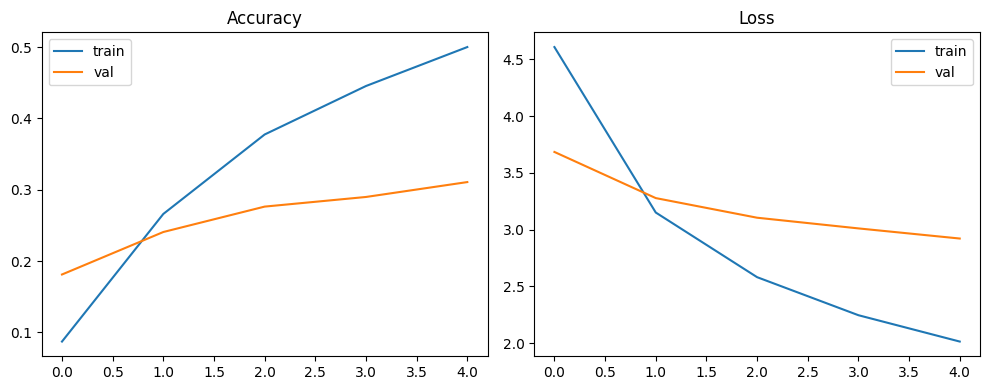

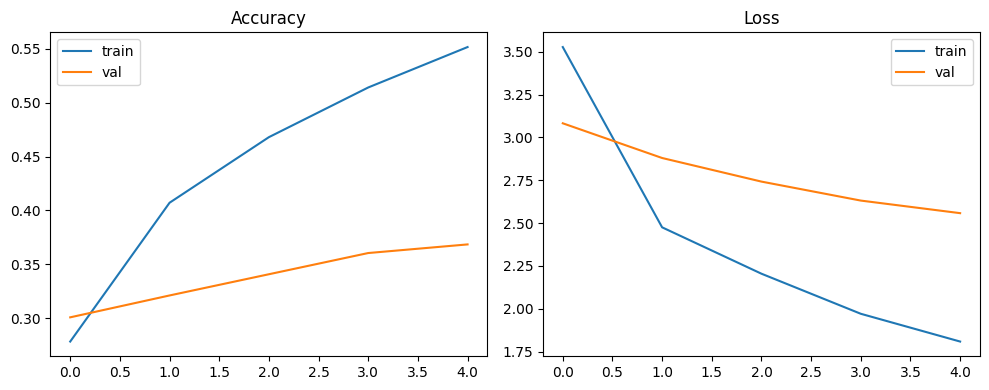

In [8]:
os.makedirs("outputs/plots", exist_ok=True)

def plot_history(history, filename):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_history(history1, "outputs/plots/mobilenet_stage1.png")
plot_history(history2, "outputs/plots/mobilenet_finetuned.png")

In [9]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

503/503 ━━━━━━━━━━━━━━━━━━━━ 194s 384ms/step - accuracy: 0.3854 - loss: 2.5172
Test loss: 2.5172078609466553
Test accuracy: 0.38539981842041016


In [10]:
os.makedirs("outputs/predictions", exist_ok=True)

for images, labels in test_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[pred_labels[i]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.savefig("outputs/predictions/sample_predictions.png")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


NameError: name 'np' is not defined